
## 2. Regresión (algoritmo alterno) — `beisbol.csv`
### Algoritmo: Regresión Ridge (`Ridge`)

**Justificación del algoritmo:**  Se eligió **Regresión Ridge** porque:
- Es uno de los algoritmos de regresión vistos en clase, tanto en el notebook de práctica *regresión
  ridge-Optimización* como en la presentación Análisis supervisado, donde se listan sus
  hiperparámetros de ajuste en `Sklearn`: `solver`, `alpha` y `fit_intercept`.
- Ridge agrega una penalización L2 al término de error L2: también
  conocida como Ridge, estima β pequeños, sirve para controlar el sobreajuste, lo que permite
  controlar la magnitud de los coeficientes y comparar cómo cambia el modelo frente a la regresión lineal
  simple cuando se ajusta el hiperparámetro de regularización `alpha`.
- Permite mostrar el proceso de optimización de hiperparámetros con un parámetro adicional (`alpha`) no
  presente en la regresión lineal ordinaria.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, RepeatedKFold, RandomizedSearchCV
from sklearn import metrics
from scipy.stats import loguniform

%matplotlib inline
sns.set_style('whitegrid')


### Paso 1. Carga de los datos

In [2]:
DATA_DIR = os.path.join('..', '..', 'Conjunto de datos para 2a. evaluación')
datos = pd.read_csv(os.path.join(DATA_DIR, 'beisbol.csv'), index_col=0)
datos.head()


,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


### Paso 2. Gráfica de dispersión — comportamiento de los datos

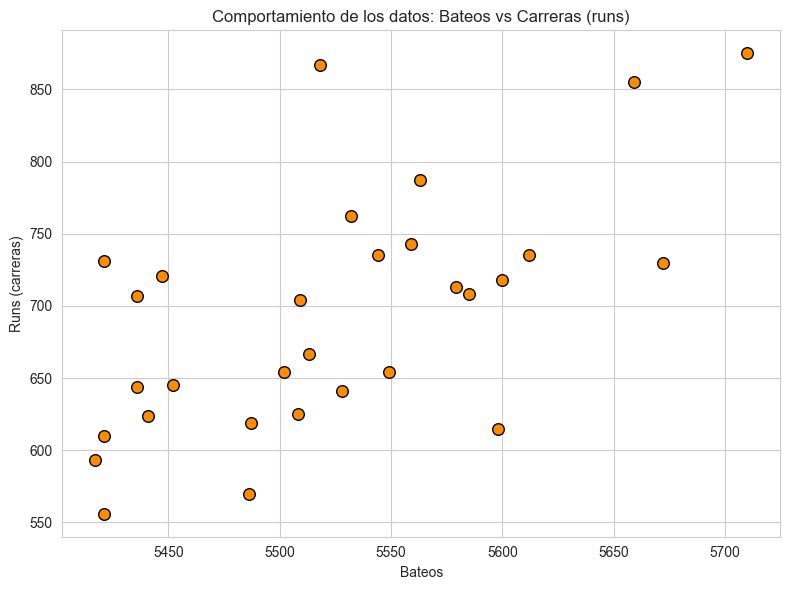

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(datos['bateos'], datos['runs'], color='darkorange', edgecolor='black', s=70)
plt.title('Comportamiento de los datos: Bateos vs Carreras (runs)')
plt.xlabel('Bateos')
plt.ylabel('Runs (carreras)')
plt.tight_layout()
plt.savefig('grafica_dispersion_beisbol_ridge.png', dpi=120)
plt.show()


### Paso 3. División de datos

In [4]:
X = datos['bateos'].values.reshape(-1, 1)
y = datos['runs'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


### Paso 4. Entrenamiento del modelo base (Ridge con alpha por defecto)

In [5]:
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(X_train, y_train)

y_pred = modelo_ridge.predict(X_test)
print('Intercepto:', modelo_ridge.intercept_)
print('Coeficiente:', modelo_ridge.coef_)


Intercepto: [-2837.75263831]
Coeficiente: [0.63897041]


### Paso 5. Evaluación del modelo base

In [6]:
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R2:', metrics.r2_score(y_test, y_pred))


MAE: 37.158588590623516
MSE: 1976.5947788507208
RMSE: 44.458911129836736
R2: 0.5399582867502007


### Paso 6. Gráfica comparativa — valores reales contra predichos

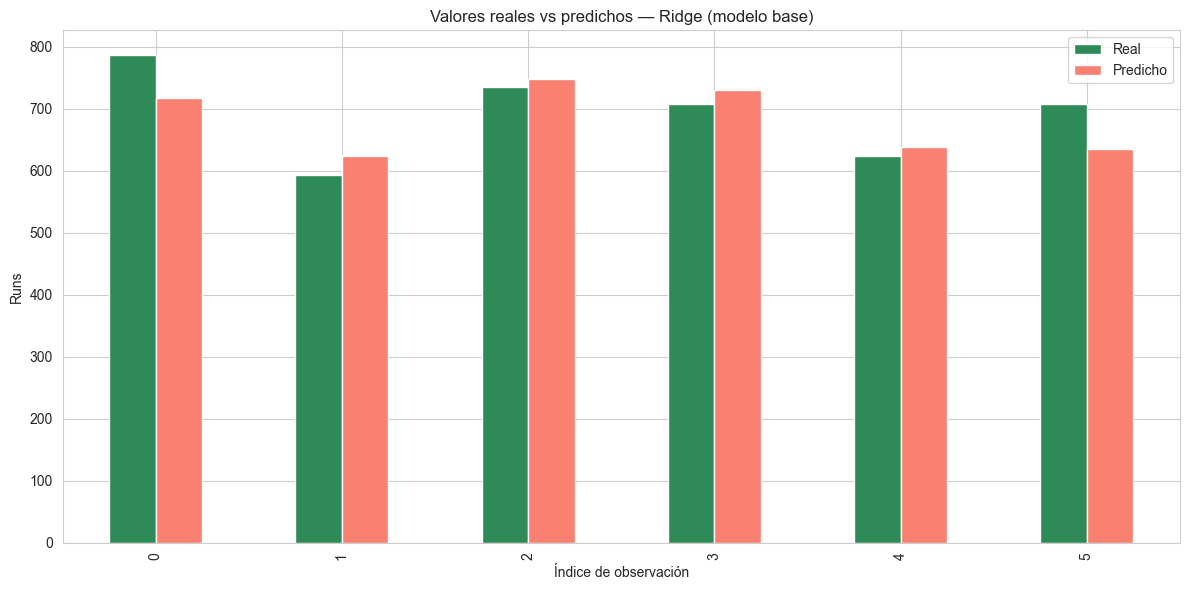

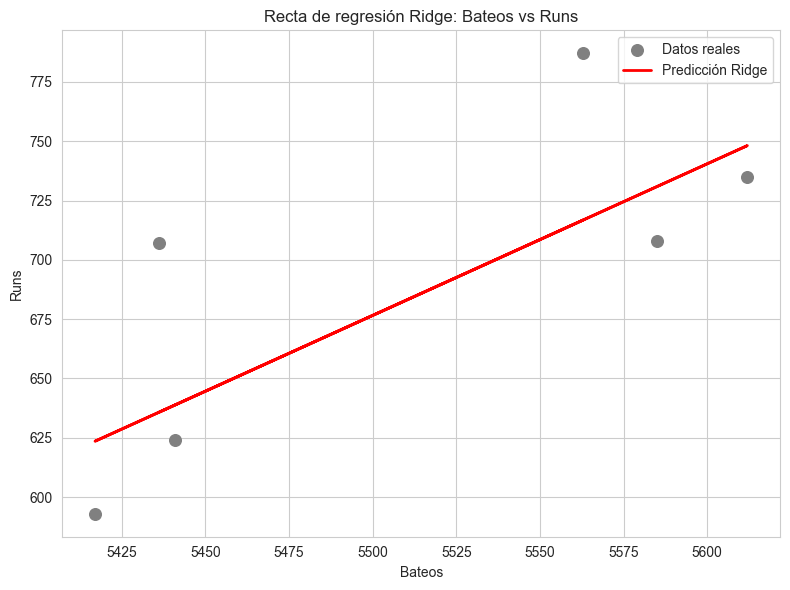

In [7]:
comparacion = pd.DataFrame({'Real': y_test.flatten(), 'Predicho': y_pred.flatten()})
comparacion.plot(kind='bar', figsize=(12, 6), color=['seagreen', 'salmon'])
plt.title('Valores reales vs predichos — Ridge (modelo base)')
plt.xlabel('Índice de observación')
plt.ylabel('Runs')
plt.tight_layout()
plt.savefig('grafica_reales_vs_predichos_ridge.png', dpi=120)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='gray', label='Datos reales', s=70)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicción Ridge')
plt.title('Recta de regresión Ridge: Bateos vs Runs')
plt.xlabel('Bateos')
plt.ylabel('Runs')
plt.legend()
plt.tight_layout()
plt.savefig('grafica_recta_ridge.png', dpi=120)
plt.show()


### Paso 7. Optimización del modelo — búsqueda de hiperparámetros (RandomizedSearchCV)
Se replica el mismo procedimiento de optimización empleado en clase para Ridge: `RandomizedSearchCV` con una
distribución log-uniforme para `alpha` (en vez de una lista fija de valores), ya que `alpha` es un
hiperparámetro continuo y esta distribución explora mejor tanto valores muy pequeños como valores grandes de
regularización.

In [8]:
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

# Espacio de búsqueda igual al usado en el notebook de clase "regresión ridge-Optimización"
space = dict()
space['alpha'] = loguniform(1e-10, 100)
space['fit_intercept'] = [True, False]
space['solver'] = ['svd', 'cholesky', 'lsqr', 'sag']

search = RandomizedSearchCV(Ridge(), space, n_iter=50, scoring='neg_mean_absolute_error',
                             n_jobs=-1, cv=cv, random_state=1)
result = search.fit(X, y)

print('Mejor puntuación (CV):', result.best_score_)
print('Mejores hiperparámetros:', result.best_params_)


Mejor puntuación (CV): -54.89727358742019
Mejores hiperparámetros: {'alpha': np.float64(6.931432262614957), 'fit_intercept': True, 'solver': 'sag'}


### Paso 8. Reentrenamiento con los mejores hiperparámetros y evaluación final

In [9]:
modelo_ridge_opt = Ridge(**result.best_params_)
modelo_ridge_opt.fit(X_train, y_train)
y_pred_opt = modelo_ridge_opt.predict(X_test)

print('--- Modelo Ridge optimizado ---')
print('Intercepto:', modelo_ridge_opt.intercept_)
print('Coeficiente:', modelo_ridge_opt.coef_)
print('MAE:', metrics.mean_absolute_error(y_test, y_pred_opt))
print('MSE:', metrics.mean_squared_error(y_test, y_pred_opt))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_opt)))
print('R2:', metrics.r2_score(y_test, y_pred_opt))


--- Modelo Ridge optimizado ---
Intercepto: [-2837.71923175]
Coeficiente: [0.63896436]
MAE: 37.158586827757595
MSE: 1976.5912010410655
RMSE: 44.45887089255715
R2: 0.5399591194659912


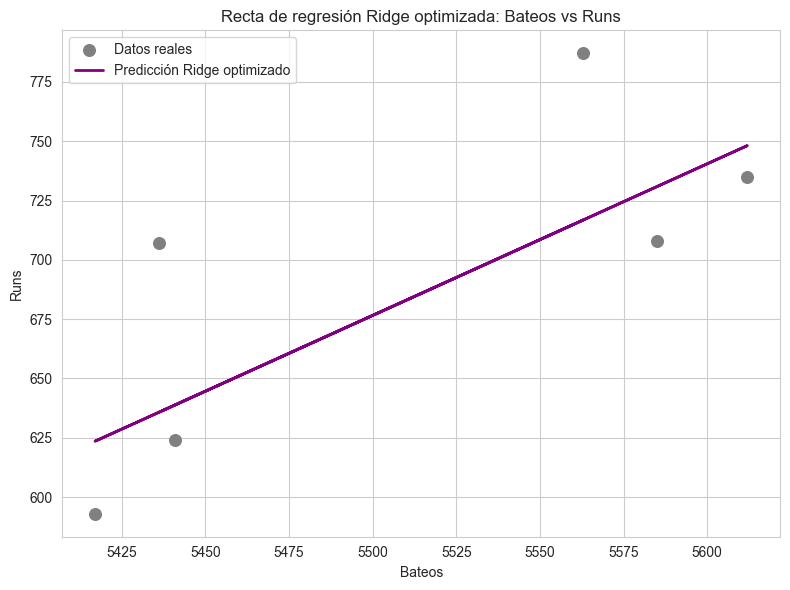

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='gray', label='Datos reales', s=70)
plt.plot(X_test, y_pred_opt, color='purple', linewidth=2, label='Predicción Ridge optimizado')
plt.title('Recta de regresión Ridge optimizada: Bateos vs Runs')
plt.xlabel('Bateos')
plt.ylabel('Runs')
plt.legend()
plt.tight_layout()
plt.savefig('grafica_recta_ridge_optimizado.png', dpi=120)
plt.show()


## Conclusión / Interpretación final
El modelo Ridge, incluso tras optimizar el hiperparámetro `alpha`, arroja resultados muy similares a la
regresión lineal simple de la sección SA. Esto es esperado dado que solo existe una variable predictora, por
lo que la penalización de Ridge (pensada para controlar coeficientes en modelos con múltiples variables
correlacionadas) tiene un efecto limitado aquí. El valor óptimo de `alpha` encontrado confirma que un
regularización mínima es suficiente para este conjunto de datos.

**Enlace al repositorio con el modelo:** https://github.com/YosueCh/2a.-Evaluaci-n-Extracci-n-de-conocimiento-en-bases-de-datos.git
